In [1]:
from os.path import curdir
from random import  random, sample, seed, randint, choice
from itertools import accumulate
import matplotlib.pyplot as plt
import numpy as np
from icecream import ic


In [2]:
def generate_universe(n: int, random_seed: int):
    seed(random_seed)
    universe = set(range(n))
    sets = list(set(sample(range(n), k=s+1)) for s in range(n))
    costs = list(10*random() + (s + random()) ** 2 for s in range(n))
    return universe, sets, costs

In [3]:
def fitness(solution: list[bool],
            universe: set[int],
            sets: list[set[int]],
            costs: list[float],
    ) -> float:
    """
    Calculates fitness function
    """
    n = len(solution)
    selected_sets = [sets[i] for i in range(n) if solution[i]]
    total_cost = sum(costs[i] for i in range(n) if solution[i])
    if not selected_sets:
        return - float("inf")
    elif set.union(*selected_sets) == universe:
        return - total_cost
    else:
        return - float("inf")


In [4]:
def tweak(solution: list[bool]) -> list[bool]:
    """
    Generates a neighbor by flipping one or more bits in a using random
    """
    new_sol = list(solution)
    while random() < 0.8:
        idx = randint(0, len(new_sol)-1)
        new_sol[idx] = not new_sol[idx]
    return new_sol


In [5]:
def hill_climbing(
        universe: set[int],
        sets_: list[set[int]],
        costs_: list[float],
        max_steps: int,
        init_solution: list[bool],
) -> tuple[float, list[bool] | None, list[float]]:
    n = len(universe)
    history = []
    current_sol = init_solution.copy()
    history.append(fitness(current_sol, universe, sets_, costs_))
    current_fit = fitness(current_sol, universe, sets_, costs_)
    for steps in range(max_steps):
        neighbor = tweak(current_sol)
        neighbor_fit = fitness(neighbor, universe, sets_, costs_)
        history.append(neighbor_fit)
        if neighbor_fit >= current_fit:
            current_fit = neighbor_fit
            current_sol = neighbor

    selected_sets = [sets[i] for i in range(n) if current_sol[i]]
    ic(max_steps, current_fit)
    print(selected_sets)
    return current_fit, current_sol, history

In [6]:
N = 100
universe, sets, costs = generate_universe(N, random_seed=0)
steps = 10_000


## All False Initial Solution

ic| max_steps: 10000, current_fit: -9813.184083206408


[{33, 66, 70, 40, 78, 81, 56, 26, 61}, {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99}]


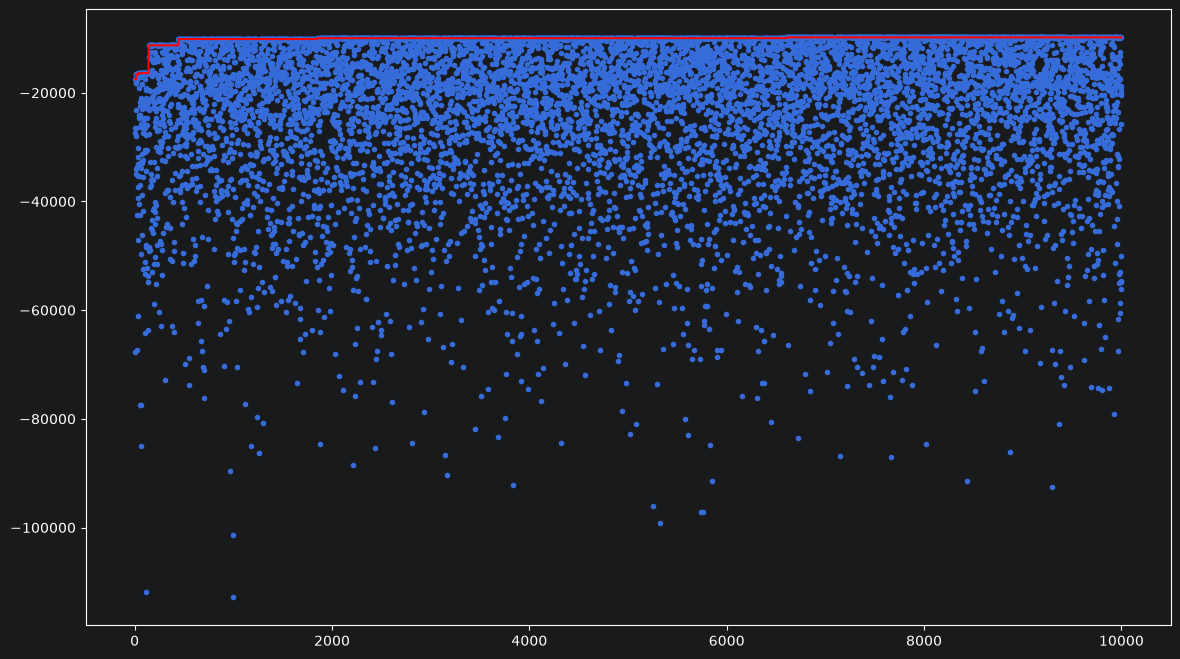

In [10]:
init_0_solution = [False] * N
_, _, history_0 = hill_climbing(universe, sets, costs, steps, init_0_solution)

plt.figure(figsize=(14, 8))
plt.plot(
    range(len(history_0)),
    list(accumulate(history_0, max)),
    color='red'
)
# plt.ylim(np.sort(list(set(history_0)))[1], 0)
_ = plt.scatter(range(len(history_0)), history_0, marker='.')

## Random Initial Solution

ic| max_steps: 10000, current_fit: -6559.403991997615


[{65, 69, 38, 70, 40, 10, 11, 13, 18, 62, 57, 30}, {33, 4, 37, 40, 73, 8, 11, 78, 49, 84, 23, 24, 60, 30}, {89, 35, 41, 74, 75, 10, 45, 78, 14, 82, 84, 53, 86, 57, 27, 63}, {5, 7, 12, 21, 23, 25, 33, 38, 44, 45, 50, 55, 59, 60, 64, 72, 76, 82, 89, 93}, {1, 5, 17, 19, 22, 26, 34, 37, 40, 42, 43, 46, 47, 48, 55, 58, 63, 68, 71, 72, 75, 77, 81, 82, 83, 86, 89}, {1, 4, 7, 8, 10, 11, 12, 13, 14, 15, 19, 21, 25, 28, 38, 42, 43, 48, 49, 53, 54, 60, 61, 63, 71, 72, 80, 93, 95}, {2, 4, 6, 7, 10, 12, 13, 16, 18, 19, 20, 30, 36, 41, 42, 45, 49, 52, 53, 58, 59, 60, 61, 62, 77, 78, 79, 82, 89, 94, 95, 97, 98, 99}, {0, 1, 3, 9, 10, 14, 15, 16, 18, 22, 23, 26, 29, 33, 37, 42, 44, 45, 46, 47, 58, 61, 76, 81, 82, 83, 84, 85, 87, 88, 91, 92, 93, 94, 96, 97, 98}, {4, 8, 9, 10, 13, 15, 17, 20, 23, 25, 26, 31, 32, 33, 35, 36, 37, 39, 40, 43, 45, 50, 51, 52, 53, 56, 66, 67, 68, 73, 74, 75, 76, 77, 83, 86, 90, 92, 95, 96, 99}]


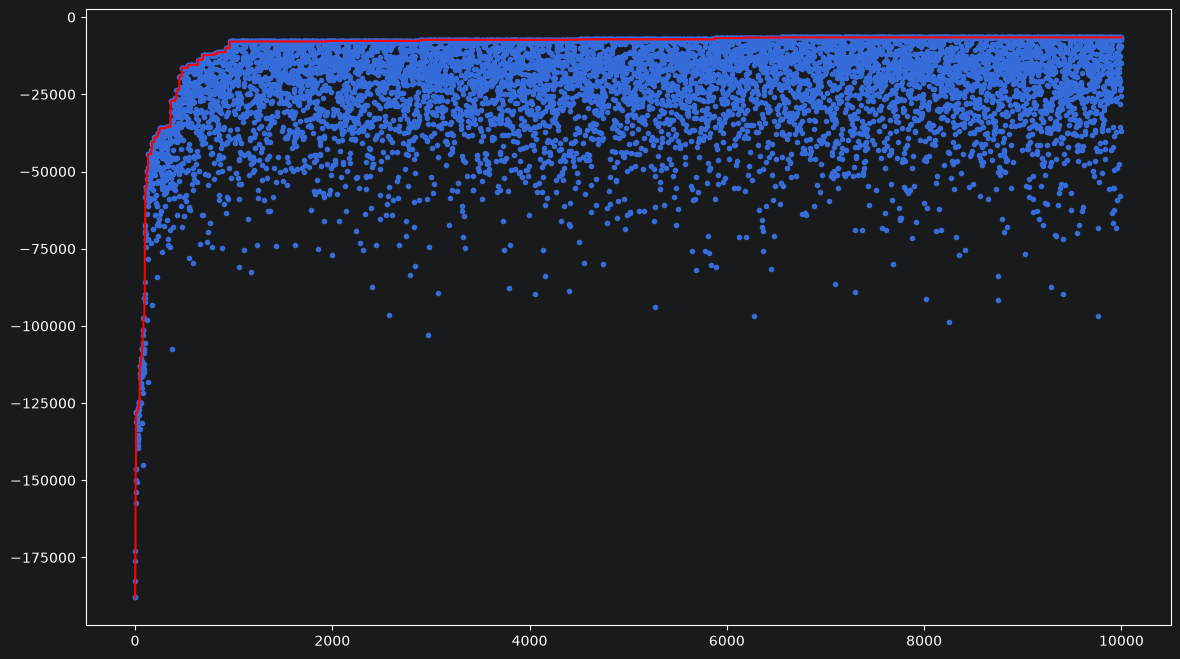

In [11]:
random_sol = list(sample([True, False], k=N, counts=(N, N))) # counts=(2, 2) --> sample([True, True , False, False], k=2)
_, _, history_rand = hill_climbing(universe, sets, costs, steps, random_sol)

plt.figure(figsize=(14, 8))
plt.plot(
    range(len(history_rand)),
    list(accumulate(history_rand, max)),
    color='red'
)
# plt.ylim(np.sort(list(set(history_rand)))[1], 0)
_ = plt.scatter(range(len(history_rand)), history_rand, marker='.')


## All True Initial Solution

[{33, 66, 70, 40, 78, 81, 56, 26, 61}, {5, 7, 12, 21, 23, 25, 33, 38, 44, 45, 50, 55, 59, 60, 64, 72, 76, 82, 89, 93}, {0, 4, 5, 6, 8, 20, 21, 33, 39, 41, 51, 53, 57, 59, 62, 63, 67, 71, 72, 77, 84, 89, 90, 91}, {0, 1, 10, 12, 15, 16, 24, 25, 27, 35, 38, 40, 51, 53, 67, 70, 77, 78, 81, 86, 87, 92, 94, 98, 99}, {1, 5, 17, 19, 22, 26, 34, 37, 40, 42, 43, 46, 47, 48, 55, 58, 63, 68, 71, 72, 75, 77, 81, 82, 83, 86, 89}, {3, 8, 10, 11, 12, 13, 14, 18, 19, 27, 29, 32, 39, 41, 53, 54, 55, 57, 62, 63, 64, 66, 67, 71, 72, 73, 76, 80, 81, 85, 86, 88, 93, 94, 97, 98}, {0, 1, 2, 3, 5, 7, 9, 17, 18, 19, 20, 21, 22, 24, 26, 27, 28, 30, 31, 32, 36, 39, 42, 43, 45, 46, 49, 50, 52, 53, 54, 59, 60, 61, 62, 65, 66, 67, 68, 69, 70, 74, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 92, 93, 94, 95, 96, 98}]


ic| max_steps: 10000, current_fit: -6853.806533127235


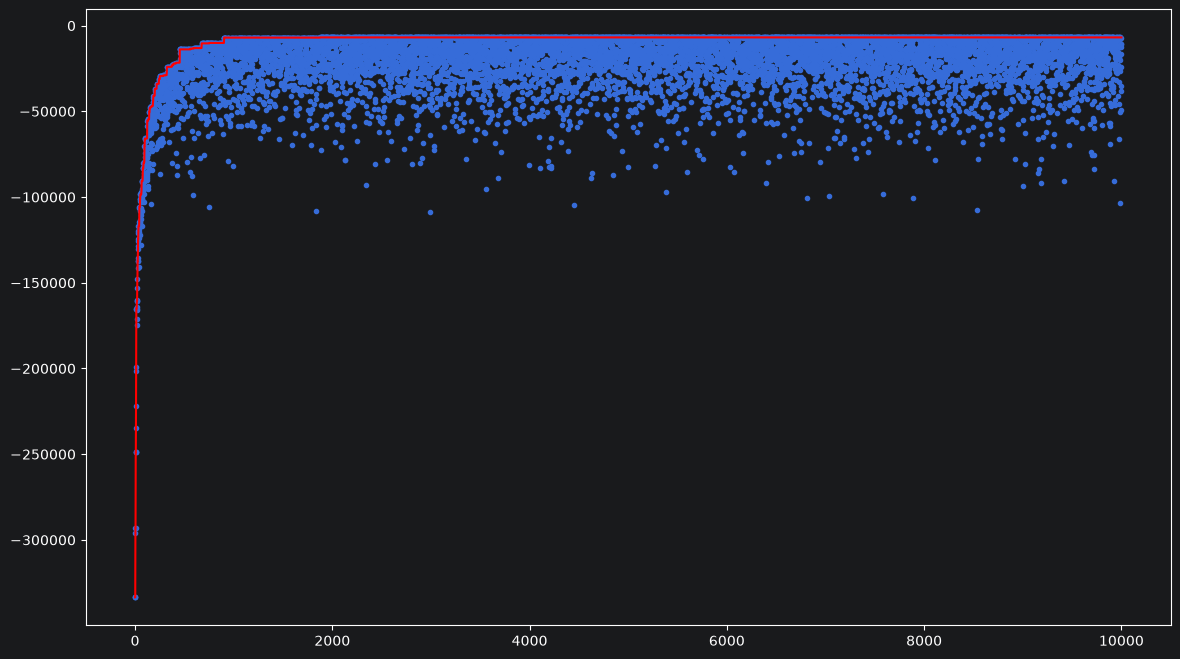

In [12]:
init_1_solution = [True] * N
_, _, history_1 = hill_climbing(universe, sets, costs, steps, init_1_solution)

plt.figure(figsize=(14, 8))
plt.plot(
    range(len(history_1)),
    list(accumulate(history_1, max)),
    color='red'
)
# plt.ylim(np.sort(list(set(history_1)))[1], 0)
_ = plt.scatter(range(len(history_1)), history_1, marker='.')
